## Lookup Table Inspector (`viz_loopup_table`)

这个 notebook 用于：
1. 对给定参数自动定位对应 `Config_N_*.json` 和 lookup table (`.pkl`)。
2. 按 `src/agent.py::calculate_heuristic_init_values` 的逻辑，计算训练开始前每个 rule action 的平均收益（以及初始 Q）。
3. 分析场景：`state=最低grid` 时，全员 `Undercut` / `Match`，某一个 seller 改为 `Above` 的收益结果。
4. 提供通用函数：支持任意 `state_idx` + 每个 seller 自定义 action（可用于 3-strats 或 4-strats）。


In [1]:
import sys
import json
import pickle
from pathlib import Path
from math import factorial

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

PREFERRED_PROJECT = 'pricing_marl'


def _locate_project_root(preferred_project=None) -> Path:
    cwd = Path.cwd().resolve()
    search_bases = [cwd, *cwd.parents]

    # 1) If preferred project is given, try it first.
    if preferred_project:
        for base in search_bases:
            direct = base if base.name == preferred_project else None
            nested = base / preferred_project
            for candidate in [direct, nested]:
                if candidate is None:
                    continue
                if (candidate / 'src' / 'config.py').exists() and (candidate / 'data').exists():
                    return candidate

    # 2) Fallback: any valid project root in current/parent chain.
    for base in search_bases:
        if (base / 'src' / 'config.py').exists() and (base / 'data').exists():
            return base
        for sub in ['pricing_marl', 'pricing_marl_nash_mono_grid']:
            candidate = base / sub
            if (candidate / 'src' / 'config.py').exists() and (candidate / 'data').exists():
                return candidate

    raise RuntimeError('Cannot locate project root containing src/config.py and data/.')


project_root = _locate_project_root(PREFERRED_PROJECT)
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.strategies import ACT_UNDERCUT, ACT_MATCH, ACT_ABOVE, ID_TO_NAME

results_root = project_root / 'data' / 'results'
lookup_dir_default = project_root / 'data' / 'lookup_tables'

sns.set_context('talk')
plt.rcParams['figure.figsize'] = (10, 5)

print(f'project_root: {project_root}')
print(f'results_root: {results_root}')
print(f'lookup_dir_default: {lookup_dir_default}')


project_root: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl
results_root: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/data/results
lookup_dir_default: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/data/lookup_tables


In [2]:
# ===== 你主要改这个参数块 =====

# 若你已经知道精确 config 路径，可直接指定；否则保持 None，走 QUERY 自动匹配
CONFIG_PATH = None

# 可选：优先某个实验目录名（例如 'scan_3strats_mu0.1_k100'）
PREFERRED_EXPERIMENT = None

# 自动匹配 Config 的参数条件（只会使用值不为 None 的字段）
QUERY = {
    'num_sellers': 10,
    'num_grids': 10,
    'active_strategies': [0, 1, 2],   # 3-strats: [0,1,2], 4-strats: [0,1,2,3]
    'mu': 0.1,
    'K': 100,
    'a_val': 2.0,
    'c_val': 1.0,
    'a0': 0.0,
    'xi': 0.1,
}

# lookup 搜索目录（会按顺序查找）
LOOKUP_DIR_CANDIDATES = [
    project_root / 'data' / 'lookup_tables',
    project_root / 'data' / 'lookup_tables_local_laptop_2026_2_18',
]

# 下面两个用于场景 2/3
TARGET_STATE_IDX = 0
DEVIATOR_SELLER_IDX = 0

# 是否画 Q 初始化 heatmap
PLOT_Q_HEATMAP = True

# ===== 你这次指定的场景（N=7, mu=0.04, 3strats）=====
SCENARIO_N = 7
SCENARIO_MU = 0.04
SCENARIO_STATE_IDX = 0
SCENARIO_DEVIATOR_IDX = 0
SCENARIO_K = 30  # 设为 None 时，会把所有匹配的 K 都打印出来


In [3]:
def _value_match(cfg_val, query_val, tol=1e-12):
    if isinstance(query_val, float):
        try:
            return abs(float(cfg_val) - query_val) <= tol
        except Exception:
            return False
    return cfg_val == query_val

def config_matches_query(cfg: dict, query: dict) -> bool:
    for k, v in query.items():
        if v is None:
            continue
        if k not in cfg:
            return False
        if not _value_match(cfg[k], v):
            return False
    return True

def find_config_candidates(results_root: Path, query: dict, preferred_experiment: str = None):
    candidates = []
    for cfg_path in sorted(results_root.rglob('Config_N_*.json')):
        try:
            with open(cfg_path, 'r') as f:
                cfg = json.load(f)
        except Exception:
            continue
        if config_matches_query(cfg, query):
            if preferred_experiment is not None and cfg_path.parent.name != preferred_experiment:
                continue
            candidates.append((cfg_path, cfg))
    return candidates

def build_lookup_filename_from_cfg(cfg: dict) -> str:
    strats_str = '_'.join(map(str, cfg['active_strategies']))
    return (
        f"lookup_N{cfg['num_sellers']}_G{cfg['num_grids']}_"
        f"mu{cfg['mu']}_a{cfg['a_val']}_c{cfg['c_val']}_a0{cfg['a0']}_"
        f"xi{cfg['xi']}_K{cfg['K']}_"
        f"strats{strats_str}_stateLow.pkl"
    )

def find_lookup_file(cfg: dict, lookup_dir_candidates):
    filename = build_lookup_filename_from_cfg(cfg)
    for d in lookup_dir_candidates:
        p = Path(d) / filename
        if p.exists():
            return p
    return None

def load_selected_config_and_lookup(config_path=None, query=None, preferred_experiment=None, results_root=None, lookup_dir_candidates=None):
    if results_root is None:
        results_root = project_root / 'data' / 'results'
    if lookup_dir_candidates is None:
        lookup_dir_candidates = [project_root / 'data' / 'lookup_tables']

    if config_path is not None:
        cfg_path = Path(config_path)
        if not cfg_path.exists():
            raise FileNotFoundError(f'Config path not found: {cfg_path}')
        with open(cfg_path, 'r') as f:
            cfg = json.load(f)
        candidates = [(cfg_path, cfg)]
    else:
        if query is None:
            raise ValueError('When config_path is None, query must be provided.')
        candidates = find_config_candidates(results_root=Path(results_root), query=query, preferred_experiment=preferred_experiment)
        if not candidates:
            raise FileNotFoundError('No config matched query. Please relax QUERY or set CONFIG_PATH directly.')

    print(f'Matched config count: {len(candidates)}')
    preview_n = min(8, len(candidates))
    for i in range(preview_n):
        cpath, ccfg = candidates[i]
        print(f"[{i}] {cpath} | N={ccfg['num_sellers']} mu={ccfg['mu']} K={ccfg['K']} strats={ccfg['active_strategies']}")

    cfg_path, cfg = candidates[0]
    lookup_path = find_lookup_file(cfg, lookup_dir_candidates)
    if lookup_path is None:
        expected = build_lookup_filename_from_cfg(cfg)
        raise FileNotFoundError(f'Lookup table not found in candidates: {lookup_dir_candidates}\nExpected filename: {expected}')

    with open(lookup_path, 'rb') as f:
        lookup_table = pickle.load(f)

    print('\nSelected files:')
    print(f'config: {cfg_path}')
    print(f'lookup: {lookup_path}')
    print(f'lookup entries: {len(lookup_table):,}')

    return cfg_path, cfg, lookup_path, lookup_table


In [4]:
def action_name(global_action_id: int) -> str:
    return ID_TO_NAME.get(global_action_id, f'Unknown({global_action_id})')

def global_to_local_actions(cfg: dict, actions_global):
    active = list(cfg['active_strategies'])
    local_actions = []
    for a in actions_global:
        if a not in active:
            raise ValueError(f'Global action {a} ({action_name(a)}) not in active_strategies={active}')
        local_actions.append(active.index(a))
    return local_actions

def _canonicalize_local_actions(local_actions):
    perm = sorted(range(len(local_actions)), key=lambda i: local_actions[i])
    canon_actions = tuple(local_actions[i] for i in perm)
    inv_perm = [0] * len(local_actions)
    for canon_pos, original_pos in enumerate(perm):
        inv_perm[original_pos] = canon_pos
    return canon_actions, perm, inv_perm

def eval_profile_from_lookup(cfg: dict, lookup_table: dict, state_idx: int, actions_global):
    n = int(cfg['num_sellers'])
    if len(actions_global) != n:
        raise ValueError(f'actions length must be {n}, got {len(actions_global)}')
    if not (0 <= state_idx < int(cfg['num_grids'])):
        raise ValueError(f"state_idx must be in [0, {cfg['num_grids'] - 1}]")

    local_actions = global_to_local_actions(cfg, actions_global)
    canon_actions, _, inv_perm = _canonicalize_local_actions(local_actions)
    key = tuple([state_idx] + list(canon_actions))

    if key not in lookup_table:
        raise KeyError(f'Lookup key not found: {key}')

    profits_canon, next_state, avg_price_k, avg_lowest_price_k = lookup_table[key]

    profits = np.zeros(n, dtype=float)
    for i in range(n):
        profits[i] = float(profits_canon[inv_perm[i]])

    return {
        'state_idx': int(state_idx),
        'actions_global': list(actions_global),
        'actions_name': [action_name(a) for a in actions_global],
        'profits': profits,
        'mean_profit_all_sellers': float(np.mean(profits)),
        'next_state_idx': int(next_state),
        'avg_price_over_k': float(avg_price_k),
        'avg_lowest_price_over_k': float(avg_lowest_price_k),
    }

def result_to_df(result: dict) -> pd.DataFrame:
    rows = []
    for i, (act_id, act_name, pi) in enumerate(zip(result['actions_global'], result['actions_name'], result['profits'])):
        rows.append({'seller': i, 'action_id': act_id, 'action_name': act_name, 'avg_profit': float(pi)})
    return pd.DataFrame(rows)

def build_one_deviator_profile(n_sellers: int, base_action: int, deviator_idx: int, deviator_action: int):
    if not (0 <= deviator_idx < n_sellers):
        raise ValueError(f'deviator_idx must be in [0, {n_sellers-1}]')
    actions = [base_action] * n_sellers
    actions[deviator_idx] = deviator_action
    return actions

def plot_profile_profit(result: dict, title: str):
    df = result_to_df(result)
    plt.figure(figsize=(10, 4.8))
    ax = sns.barplot(data=df, x='seller', y='avg_profit', hue='action_name', dodge=False)
    ax.set_title(title)
    ax.set_xlabel('Seller')
    ax.set_ylabel('Avg Profit over K')
    plt.legend(title='Action', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [5]:
def action_profile_multiplicity(canon_actions):
    counts = {}
    for a in canon_actions:
        counts[a] = counts.get(a, 0) + 1
    denom = 1
    for v in counts.values():
        denom *= factorial(v)
    return factorial(len(canon_actions)) // denom

def compute_heuristic_init_from_lookup(cfg: dict, lookup_table: dict):
    num_grids = int(cfg['num_grids'])
    num_actions = len(cfg['active_strategies'])
    gamma = float(cfg['gamma'])

    profit_sums = np.zeros((num_grids, num_actions), dtype=float)
    counts = np.zeros((num_grids, num_actions), dtype=float)

    for key, val in lookup_table.items():
        start_state = key[0]
        canon_actions = key[1:]
        profits = val[0]
        multiplicity = action_profile_multiplicity(canon_actions)
        for i, act_idx in enumerate(canon_actions):
            profit_sums[start_state, act_idx] += float(profits[i]) * multiplicity
            counts[start_state, act_idx] += multiplicity

    with np.errstate(divide='ignore', invalid='ignore'):
        avg_profit_before_div = np.divide(profit_sums, counts, out=np.zeros_like(profit_sums), where=counts > 0)

    q_init = avg_profit_before_div / (1.0 - gamma)
    return avg_profit_before_div, q_init, counts

def summarize_action_init(cfg: dict, avg_profit_before_div: np.ndarray, q_init: np.ndarray) -> pd.DataFrame:
    rows = []
    for local_idx, global_id in enumerate(cfg['active_strategies']):
        rows.append({
            'local_action_idx': local_idx,
            'global_action_id': global_id,
            'action_name': action_name(global_id),
            'avg_profit_all_states': float(np.mean(avg_profit_before_div[:, local_idx])),
            'avg_profit_state0': float(avg_profit_before_div[0, local_idx]),
            'q_init_all_states': float(np.mean(q_init[:, local_idx])),
            'q_init_state0': float(q_init[0, local_idx]),
        })
    return pd.DataFrame(rows).sort_values('local_action_idx').reset_index(drop=True)

def plot_q_init_heatmap(cfg: dict, values: np.ndarray, title: str):
    action_labels = [action_name(gid) for gid in cfg['active_strategies']]
    df_hm = pd.DataFrame(values, columns=action_labels)
    df_hm.index.name = 'state_idx'
    # Show state 0 at bottom and highest state at top.
    df_hm_plot = df_hm.iloc[::-1]
    plt.figure(figsize=(1.4 * len(action_labels) + 5, 5.5))
    sns.heatmap(df_hm_plot, cmap='viridis', annot=False)
    plt.title(title)
    plt.xlabel('Action')
    plt.ylabel('State')
    plt.tight_layout()
    plt.show()


Matched config count: 1
[0] /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/data/results/scan_3strats_mu0.1_k100/Config_N_10.json | N=10 mu=0.1 K=100 strats=[0, 1, 2]

Selected files:
config: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/data/results/scan_3strats_mu0.1_k100/Config_N_10.json
lookup: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/data/lookup_tables/lookup_N10_G10_mu0.1_a2.0_c1.0_a00.0_xi0.1_K100_strats0_1_2_stateLow.pkl
lookup entries: 660

Loaded config summary:
N=10, G=10, mu=0.1, K=100, gamma=0.95
active_strategies=[0, 1, 2] -> ['Undercut', 'Match', 'Above']

[1] 训练开始前，每个 rule action 的平均收益（按 Q 初始化逻辑）


,local_action_idx,global_action_id,action_name,avg_profit_all_states,avg_profit_state0,q_init_all_states,q_init_state0
0,0,0,Undercut,0.000900,-0.002242,0.017993,-0.044848
1,1,1,Match,0.001380,-0.002238,0.027607,-0.044757
2,2,2,Above,0.005608,0.004464,0.112170,0.089284


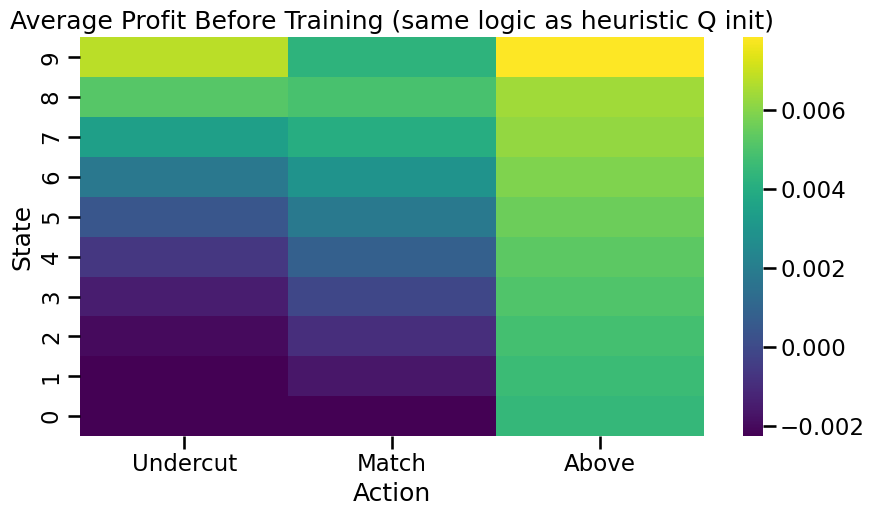

In [6]:
cfg_path, cfg, lookup_path, lookup_table = load_selected_config_and_lookup(
    config_path=CONFIG_PATH,
    query=QUERY,
    preferred_experiment=PREFERRED_EXPERIMENT,
    results_root=results_root,
    lookup_dir_candidates=LOOKUP_DIR_CANDIDATES,
)

print('\nLoaded config summary:')
print(f"N={cfg['num_sellers']}, G={cfg['num_grids']}, mu={cfg['mu']}, K={cfg['K']}, gamma={cfg['gamma']}")
print(f"active_strategies={cfg['active_strategies']} -> {[action_name(a) for a in cfg['active_strategies']]}")

avg_profit_before_div, q_init, q_counts = compute_heuristic_init_from_lookup(cfg, lookup_table)
init_summary_df = summarize_action_init(cfg, avg_profit_before_div, q_init)

print('\n[1] 训练开始前，每个 rule action 的平均收益（按 Q 初始化逻辑）')
display(init_summary_df)

if PLOT_Q_HEATMAP:
    plot_q_init_heatmap(cfg, avg_profit_before_div, title='Average Profit Before Training (same logic as heuristic Q init)')


[2] All at lowest grid, baseline=Undercut, one deviator=Above
state_idx=0, deviator=0
all-seller mean profit = -0.0013407366


,seller,action_id,action_name,avg_profit
0,0,2,Above,0.003318
1,1,0,Undercut,-0.001858
2,2,0,Undercut,-0.001858
3,3,0,Undercut,-0.001858
4,4,0,Undercut,-0.001858
5,5,0,Undercut,-0.001858
6,6,0,Undercut,-0.001858
7,7,0,Undercut,-0.001858
8,8,0,Undercut,-0.001858
9,9,0,Undercut,-0.001858


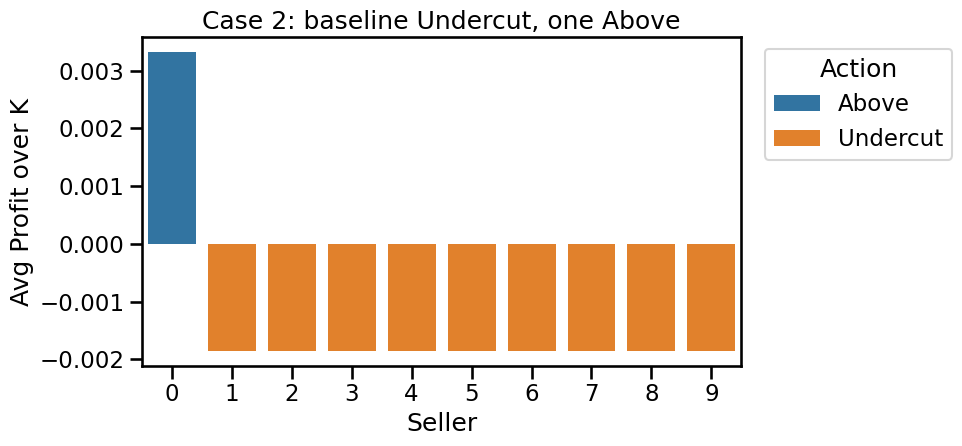


[3] All at lowest grid, baseline=Match, one deviator=Above
state_idx=0, deviator=0
deviator avg profit = 0.0033183605
all-seller mean profit = -0.0013407366


,seller,action_id,action_name,avg_profit
0,0,2,Above,0.003318
1,1,1,Match,-0.001858
2,2,1,Match,-0.001858
3,3,1,Match,-0.001858
4,4,1,Match,-0.001858
5,5,1,Match,-0.001858
6,6,1,Match,-0.001858
7,7,1,Match,-0.001858
8,8,1,Match,-0.001858
9,9,1,Match,-0.001858


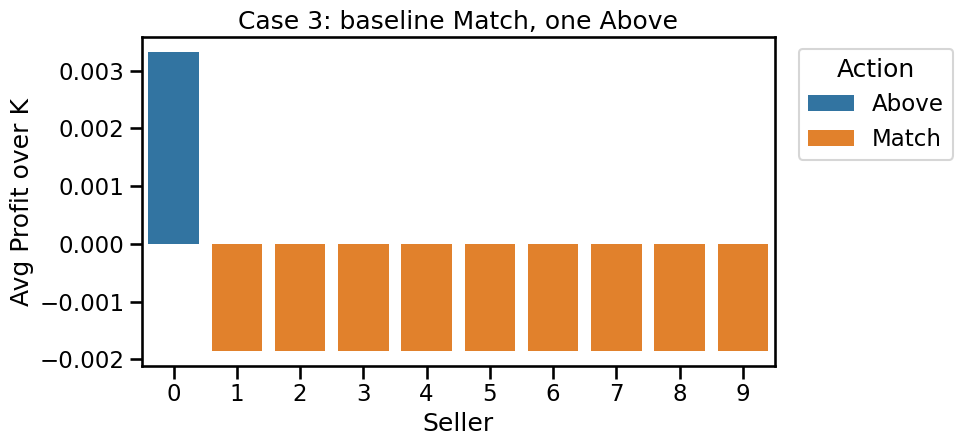

In [7]:
# [2] state=最低grid(0), 全员 Undercut, 只有一个 seller 改成 Above
n = int(cfg['num_sellers'])
actions_case2 = build_one_deviator_profile(
    n_sellers=n,
    base_action=ACT_UNDERCUT,
    deviator_idx=DEVIATOR_SELLER_IDX,
    deviator_action=ACT_ABOVE,
)
res_case2 = eval_profile_from_lookup(cfg, lookup_table, state_idx=TARGET_STATE_IDX, actions_global=actions_case2)

df_case2 = result_to_df(res_case2)
print('[2] All at lowest grid, baseline=Undercut, one deviator=Above')
print(f'state_idx={TARGET_STATE_IDX}, deviator={DEVIATOR_SELLER_IDX}')
print(f"all-seller mean profit = {res_case2['mean_profit_all_sellers']:.10f}")
display(df_case2)
plot_profile_profit(res_case2, 'Case 2: baseline Undercut, one Above')

# [3] state=最低grid(0), 全员 Match, 只有一个 seller 改成 Above
actions_case3 = build_one_deviator_profile(
    n_sellers=n,
    base_action=ACT_MATCH,
    deviator_idx=DEVIATOR_SELLER_IDX,
    deviator_action=ACT_ABOVE,
)
res_case3 = eval_profile_from_lookup(cfg, lookup_table, state_idx=TARGET_STATE_IDX, actions_global=actions_case3)

df_case3 = result_to_df(res_case3)
print('\n[3] All at lowest grid, baseline=Match, one deviator=Above')
print(f'state_idx={TARGET_STATE_IDX}, deviator={DEVIATOR_SELLER_IDX}')
print(f"deviator avg profit = {res_case3['profits'][DEVIATOR_SELLER_IDX]:.10f}")
print(f"all-seller mean profit = {res_case3['mean_profit_all_sellers']:.10f}")
display(df_case3)
plot_profile_profit(res_case3, 'Case 3: baseline Match, one Above')


[4] Custom profile result
state_idx=0
actions=['Undercut', 'Match', 'Above', 'Undercut', 'Match', 'Above', 'Undercut', 'Match', 'Above', 'Undercut']
mean_profit_all_sellers=-0.0003617614
next_state_idx=0


,seller,action_id,action_name,avg_profit
0,0,0,Undercut,-0.002202
1,1,1,Match,-0.002202
2,2,2,Above,0.003931
3,3,0,Undercut,-0.002202
4,4,1,Match,-0.002202
5,5,2,Above,0.003931
6,6,0,Undercut,-0.002202
7,7,1,Match,-0.002202
8,8,2,Above,0.003931
9,9,0,Undercut,-0.002202


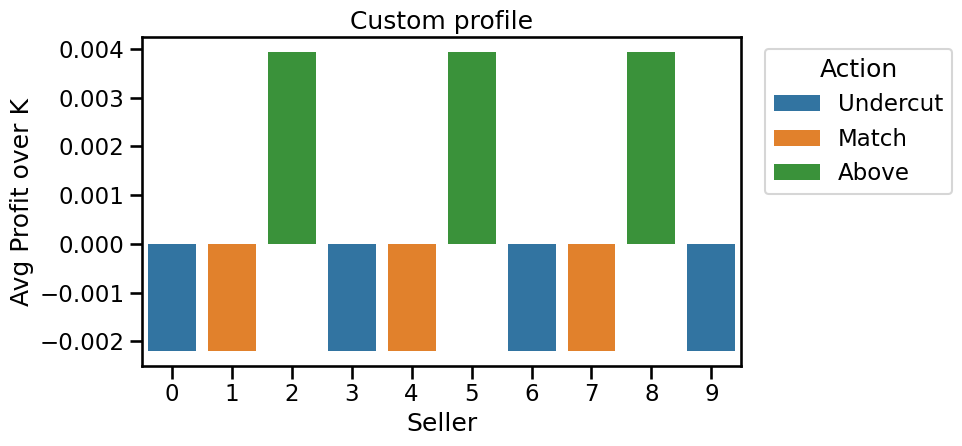

In [8]:
# [4] 通用接口示例：任意 state + 任意 seller action 组合
# 你之后做类似 2/3 的分析时，直接改这两行即可。

custom_state_idx = 0
active = list(cfg['active_strategies'])
custom_actions = [active[i % len(active)] for i in range(cfg['num_sellers'])]

custom_res = eval_profile_from_lookup(cfg, lookup_table, state_idx=custom_state_idx, actions_global=custom_actions)

print('[4] Custom profile result')
print(f'state_idx={custom_state_idx}')
print(f"actions={custom_res['actions_name']}")
print(f"mean_profit_all_sellers={custom_res['mean_profit_all_sellers']:.10f}")
print(f"next_state_idx={custom_res['next_state_idx']}")

display(result_to_df(custom_res))
plot_profile_profit(custom_res, 'Custom profile')

# 你也可以用这种方式快速构造 one-deviator：
# actions = build_one_deviator_profile(cfg['num_sellers'], ACT_UNDERCUT, 2, ACT_ABOVE)
# res = eval_profile_from_lookup(cfg, lookup_table, state_idx=0, actions_global=actions)


In [9]:
# [5] 指定场景输出：N=7, mu=0.04, 3-strats, state=0, 1个Above + 其余Undercut

def _scenario_candidates_for_n_mu(n, mu, k=None):
    q = {
        'num_sellers': n,
        'active_strategies': [0, 1, 2],
        'mu': mu,
        'K': k,
    }
    return find_config_candidates(results_root=results_root, query=q, preferred_experiment=None)


def _eval_one_cfg_path(cfg_path, state_idx, deviator_idx):
    with open(cfg_path, 'r') as f:
        cfg_local = json.load(f)
    lookup_path_local = find_lookup_file(cfg_local, LOOKUP_DIR_CANDIDATES)
    if lookup_path_local is None:
        raise FileNotFoundError(f'lookup not found for {cfg_path}')

    with open(lookup_path_local, 'rb') as f:
        lookup_local = pickle.load(f)

    actions = build_one_deviator_profile(
        n_sellers=int(cfg_local['num_sellers']),
        base_action=ACT_UNDERCUT,
        deviator_idx=deviator_idx,
        deviator_action=ACT_ABOVE,
    )
    res = eval_profile_from_lookup(
        cfg_local,
        lookup_local,
        state_idx=state_idx,
        actions_global=actions,
    )
    out = result_to_df(res).copy()
    out['K'] = int(cfg_local['K'])
    out['mu'] = float(cfg_local['mu'])
    out['N'] = int(cfg_local['num_sellers'])
    out['state_idx'] = int(state_idx)
    out['config_path'] = str(cfg_path)
    return out, res


cands = _scenario_candidates_for_n_mu(SCENARIO_N, SCENARIO_MU, SCENARIO_K)
if not cands:
    raise FileNotFoundError(
        f'No config found for N={SCENARIO_N}, mu={SCENARIO_MU}, K={SCENARIO_K}, strats=[0,1,2]'
    )

print(f'Matched {len(cands)} config(s) for scenario query.')

all_tables = []
summary_rows = []
for cfg_path, cfg_local in cands:
    tbl, res = _eval_one_cfg_path(
        cfg_path=cfg_path,
        state_idx=SCENARIO_STATE_IDX,
        deviator_idx=SCENARIO_DEVIATOR_IDX,
    )
    all_tables.append(tbl)
    summary_rows.append({
        'K': int(cfg_local['K']),
        'deviator_profit': float(res['profits'][SCENARIO_DEVIATOR_IDX]),
        'others_profit_mean': float(np.mean([p for i, p in enumerate(res['profits']) if i != SCENARIO_DEVIATOR_IDX])),
        'all_sellers_mean_profit': float(res['mean_profit_all_sellers']),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('K').reset_index(drop=True)
print('\nScenario summary by K:')
display(summary_df)

full_df = pd.concat(all_tables, ignore_index=True)
full_df = full_df.sort_values(['K', 'seller']).reset_index(drop=True)
print('\nPer-seller profits (Above seller + 6 Undercut sellers):')
display(full_df[['K', 'seller', 'action_name', 'avg_profit', 'state_idx', 'N', 'mu']])

if SCENARIO_K is not None:
    one_k_df = full_df[full_df['K'] == SCENARIO_K].copy()
    print(f'\nSelected K={SCENARIO_K} details:')
    display(one_k_df[['seller', 'action_name', 'avg_profit']])


Matched 1 config(s) for scenario query.

Scenario summary by K:


,K,deviator_profit,others_profit_mean,all_sellers_mean_profit
0,30,0.000304,-0.013705,-0.011704



Per-seller profits (Above seller + 6 Undercut sellers):


,K,seller,action_name,avg_profit,state_idx,N,mu
0,30,0,Above,0.000304,0,7,0.04
1,30,1,Undercut,-0.013705,0,7,0.04
2,30,2,Undercut,-0.013705,0,7,0.04
3,30,3,Undercut,-0.013705,0,7,0.04
4,30,4,Undercut,-0.013705,0,7,0.04
5,30,5,Undercut,-0.013705,0,7,0.04
6,30,6,Undercut,-0.013705,0,7,0.04



Selected K=30 details:


,seller,action_name,avg_profit
0,0,Above,0.000304
1,1,Undercut,-0.013705
2,2,Undercut,-0.013705
3,3,Undercut,-0.013705
4,4,Undercut,-0.013705
5,5,Undercut,-0.013705
6,6,Undercut,-0.013705
